# 13장 실습 — 검출기의 순위도 뒤집힌다

12장에서 네 신호를 만들고 비용과 성능을 같은 표에 놓았다. 하나를 골라 쓰면 되는가.

Sentinel 의 저자들이 그 질문에 답을 줬다. 그들은 실패를 두 종류로 나눈다.

- **시간적 실패** — 정책의 행동 분포가 갑자기 어긋난다. 튀고 떨린다
- **비시간적 실패** — 겉보기에는 매끄럽게 움직이는데 **과제를 향하지 않는다**

성질이 다르므로 하나의 검출기로는 둘 다 잡히지 않는다. Sentinel 은 두 검출기를 함께 돌려 **각 단일 검출기 대비 실패를 18% 더 검출**했다고 보고한다.

그리고 더 불편한 결과가 2026년에 나왔다. VLA-FAIL 의 표에서 어떤 검출기가 한 과제에 0.92 인데 다른 정책에서 0.73 이고, 같은 자리에서 다른 검출기가 0.35 와 0.95 로 **정확히 맞바뀐다.** 6장에서 양자화 방법의 순위가 뒤집힌 것과 같은 구조다.

이 노트북은 두 정책과 두 장면에서 검출기를 맞세운다. 예상한 것과 다른 결과가 나오는데, 그 어긋남이 더 쓸모 있다.

실행 시간은 CPU에서 7분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def auroc(score, label):
    s = np.asarray(score, float)
    y = np.asarray(label, int)
    n1, n0 = y.sum(), (1 - y).sum()
    if n1 == 0 or n0 == 0:
        return float("nan")
    order = np.argsort(s)
    rank = np.empty_like(order, float)
    rank[order] = np.arange(1, len(s) + 1)
    u = rank[y == 1].sum() - n1 * (n1 + 1) / 2
    return float(u / (n1 * n0))


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (68s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 두 종류의 실패를 만든다

3권 17장에서 실패에 이름을 붙였다. 여기서는 그 분류를 Sentinel 의 두 축으로 접는다.

- **F3 미달 · F1 도달 실패** — 매끄럽게 움직이는데 과제를 완성하지 못한다 → **비시간적**
- **F2 방향 오류 · F5 헤맴** — 방향이 어긋나거나 목표 언저리에서 떨린다 → **시간적**

두 종류를 각각 많이 만들려면 교란을 다르게 걸어야 한다. 3권 16장에서 축마다 다른 실패가 나온다는 것을 봤으므로 그것을 쓴다.

- **관측 편향** — 정책이 엉뚱한 자리를 목표로 삼고 거기서 멈춘다. 움직임은 매끄럽다
- **관측 잡음** — 매 스텝 추정이 흔들려 명령이 떨린다

In [6]:
SCENE = {
    "매끄럽게 실패": dict(bias=(.010, -.007), lat=1, mu=.80),
    "떨면서 실패": dict(noise=.012, lat=1, mu=.80),
}


class Noisy(Pert):
    def __init__(self, n, seed=0, noise=0., **kw):
        self.noise = noise
        super().__init__(n, seed, **kw)

    def obs(self):
        o = super().obs()
        if self.noise:
            e = self.rng.normal(0, self.noise * 10., (self.n, 2))
            o[:, 0:2] += e.astype(np.float32)
            o[:, 4:6] -= e.astype(np.float32)
        return o


print("두 장면:", ", ".join(SCENE))

두 장면: 매끄럽게 실패, 떨면서 실패


## 두 검출기

12장의 네 신호 중 성격이 뚜렷이 다른 둘을 고른다.

- **행동 불일치** — 연속한 명령의 차이. 떨림을 잡는 데 맞는 신호다
- **재구성 오차** — 관측이 학습 분포에서 얼마나 벗어났는지. 엉뚱한 자리에 가 있는 것을 잡는 데 맞다

성격이 다르다는 것이 요점이고, 그것이 Sentinel 의 두 축에 대응한다.

In [7]:
class AutoEnc(nn.Module):
    def __init__(self, d=8, h=16, z=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.Tanh(),
                                 nn.Linear(h, z))
        self.dec = nn.Sequential(nn.Linear(z, h), nn.Tanh(),
                                 nn.Linear(h, d))

    def forward(self, x):
        return self.dec(self.enc(x))


def collect_ok(policy, n=64, steps=400, seed=5):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    seen = [[] for _ in range(n)]
    keep = []
    for t in range(steps):
        o = env.obs()
        for i in range(n):
            seen[i].append(o[i])
        with torch.no_grad():
            a = policy.dist(torch.from_numpy(o)).sample().numpy()
        _, dn, sc = env.step(a)
        k = 0
        for i in range(n):
            if dn[i]:
                if sc[k] > .5:
                    keep += seen[i]
                seen[i] = []
                k += 1
    return torch.from_numpy(np.stack(keep))


def train_ae(X, epochs=200, seed=5):
    torch.manual_seed(seed)
    m = AutoEnc()
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    mu, sd = X.mean(0, keepdim=True), X.std(0, keepdim=True) + 1e-6
    Z = (X - mu) / sd
    n = Z.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 1024):
            j = idx[k:k + 1024]
            loss = ((m(Z[j]) - Z[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m, mu, sd


t0 = time.time()
POLS = {"정책 A": POLICY, "정책 B": train_rl(seed=1)}
print(f"정책 둘 준비 끝  ({time.time() - t0:.0f}s)")
AE, MU, SD = train_ae(collect_ok(POLICY))
print(f"자동부호기 학습 끝  ({time.time() - t0:.0f}s)")

정책 둘 준비 끝  (66s)


자동부호기 학습 끝  (74s)


In [8]:
DET = ["행동 불일치", "재구성 오차"]


def run_scene(policy, scene, seed=999, n=128, reps=3):
    torch.manual_seed(seed)
    env = Noisy(n, seed, **SCENE[scene])
    acc = {k: [[] for _ in range(n)] for k in DET}
    prev = np.zeros((n, 2), np.float32)
    rows = []
    for t in range(EP * reps):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = policy.dist(ot).sample().numpy()
            z = (ot - MU) / SD
            rec = ((AE(z) - z) ** 2).mean(-1).numpy()
        sig = {"행동 불일치": np.abs(a - prev).mean(1),
               "재구성 오차": rec}
        for k in DET:
            for i in range(n):
                acc[k][i].append(float(sig[k][i]))
        prev = a
        _, dn, sc = env.step(a)
        j = 0
        for i in range(n):
            if dn[i]:
                rows.append({k: np.array(acc[k][i]) for k in DET}
                            | {"fail": 1 - int(sc[j] > .5)})
                for k in DET:
                    acc[k][i] = []
                j += 1
    return rows


def summarize(rows, key, T=55):
    return auroc([r[key][:T].mean() for r in rows],
                 [r["fail"] for r in rows])


t0 = time.time()
TAB = {}
for pk, pol in POLS.items():
    for sk in SCENE:
        TAB[(pk, sk)] = run_scene(pol, sk)
    print(f"{pk} 끝  ({time.time() - t0:.0f}s)")

print()
cols = [(p, s) for p in POLS for s in SCENE]
HEAD = "".join(pad(f"{p[2]} · {s[:2]}", 14, True)
               for p, s in cols)
print(pad("검출기", 14) + HEAD)
for k in DET:
    print(pad(k, 14)
          + "".join(pad(f"{summarize(TAB[c], k):.2f}", 14, True)
                   for c in cols))
print()
print("값은 AUROC — 55 스텝까지만 보고 실패를 맞힌 것")
for c in cols:
    fr = sum(r["fail"] for r in TAB[c]) / len(TAB[c])
    print(pad(f"{c[0]} · {c[1]}", 24)
          + pad(f"실패율 {fr:.2f}", 14, True))

정책 A 끝  (12s)


정책 B 끝  (24s)

검출기                · 매끄        · 떨면        · 매끄        · 떨면
행동 불일치             0.26          0.12          0.43          0.42
재구성 오차             0.77          0.86          0.74          0.80

값은 AUROC — 55 스텝까지만 보고 실패를 맞힌 것
정책 A · 매끄럽게 실패     실패율 0.36
정책 A · 떨면서 실패       실패율 0.55
정책 B · 매끄럽게 실패     실패율 0.67
정책 B · 떨면서 실패       실패율 0.48


## 순위가 뒤집히는 자리

두 줄을 열마다 비교한다. 어느 검출기가 이기는지가 **열마다 달라지면** VLA-FAIL 이 본 것을 재현한 것이다.

In [9]:
print(pad("조건", 26) + pad("1등 검출기", 16, True)
      + pad("1등", 8, True) + pad("2등", 8, True))
for c in cols:
    v = {k: summarize(TAB[c], k) for k in DET}
    o = sorted(DET, key=lambda k: -v[k])
    print(pad(f"{c[0]} · {c[1]}", 26) + pad(o[0], 16, True)
          + pad(f"{v[o[0]]:.2f}", 8, True)
          + pad(f"{v[o[1]]:.2f}", 8, True))

조건                            1등 검출기     1등     2등
정책 A · 매끄럽게 실패         재구성 오차    0.77    0.26
정책 A · 떨면서 실패           재구성 오차    0.86    0.12
정책 B · 매끄럽게 실패         재구성 오차    0.74    0.43
정책 B · 떨면서 실패           재구성 오차    0.80    0.42


## 둘을 합치면 — 그냥 더하면 안 된다

Sentinel 의 처방은 고르는 것이 아니라 **함께 쓰는 것**이다. 두 신호를 표준화해 더해 본다.

In [10]:
def combo_naive(rows, T=55):
    vals = []
    for k in DET:
        v = np.array([r[k][:T].mean() for r in rows])
        vals.append((v - v.mean()) / (v.std() + 1e-9))
    return auroc(sum(vals), [r["fail"] for r in rows])


print(pad("조건", 26) + pad("행동 불일치", 14, True)
      + pad("재구성 오차", 14, True) + pad("그냥 더함", 12, True))
for c in cols:
    a = summarize(TAB[c], DET[0])
    b = summarize(TAB[c], DET[1])
    print(pad(f"{c[0]} · {c[1]}", 26) + pad(f"{a:.2f}", 14, True)
          + pad(f"{b:.2f}", 14, True)
          + pad(f"{combo_naive(TAB[c]):.2f}", 12, True))

조건                         행동 불일치   재구성 오차   그냥 더함
정책 A · 매끄럽게 실패              0.26          0.77        0.40
정책 A · 떨면서 실패                0.12          0.86        0.28
정책 B · 매끄럽게 실패              0.43          0.74        0.53
정책 B · 떨면서 실패                0.42          0.80        0.55


## 부호를 맞춰서 합친다

고칠 방법은 간단하다. 각 신호의 부호를 **데이터로 정하고** 더하면 된다. 다만 같은 데이터로 부호를 정하고 성능을 재면 결과가 부풀려지므로, 판을 절반으로 갈라 **앞쪽에서 부호를 정하고 뒤쪽에서 채점한다.**

In [11]:
def oriented(rows, T=55):
    """앞 절반으로 부호를 정하고 뒤 절반에서 채점한다"""
    h = len(rows) // 2
    fit, test = rows[:h], rows[h:]
    sign = {}
    for k in DET:
        sign[k] = 1. if summarize(fit, k, T) >= .5 else -1.
    vals = []
    for k in DET:
        v = np.array([r[k][:T].mean() for r in test])
        vals.append(sign[k] * (v - v.mean()) / (v.std() + 1e-9))
    y = [r["fail"] for r in test]
    single = {k: auroc(sign[k] * np.array(
        [r[k][:T].mean() for r in test]), y) for k in DET}
    return auroc(sum(vals), y), single, sign


print(pad("조건", 26) + pad("불일치 보정", 14, True)
      + pad("재구성 보정", 14, True)
      + pad("맞춰서 합침", 14, True))
gain = []
for c in cols:
    cc, single, sign = oriented(TAB[c])
    best = max(single.values())
    gain.append(cc - best)
    print(pad(f"{c[0]} · {c[1]}", 26)
          + pad(f"{single[DET[0]]:.2f}", 14, True)
          + pad(f"{single[DET[1]]:.2f}", 14, True)
          + pad(f"{cc:.2f}", 14, True))
print()
print(f"합친 쪽이 각 조건의 1등보다 나은 폭: "
      f"평균 {np.mean(gain):+.3f}  최악 {min(gain):+.3f}")
print("(뒤 절반 판에서만 채점한 값)")

조건                         불일치 보정   재구성 보정   맞춰서 합침
정책 A · 매끄럽게 실패              0.76          0.79          0.76
정책 A · 떨면서 실패                0.89          0.90          0.89
정책 B · 매끄럽게 실패              0.54          0.72          0.67
정책 B · 떨면서 실패                0.60          0.83          0.79

합친 쪽이 각 조건의 1등보다 나은 폭: 평균 -0.032  최악 -0.049
(뒤 절반 판에서만 채점한 값)


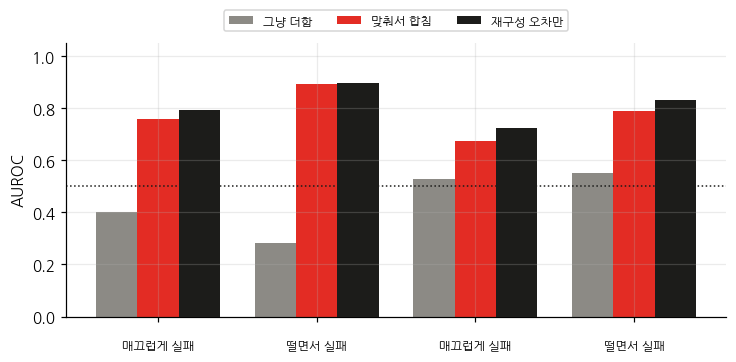

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
x = np.arange(len(cols))
w = .26
bars = {"그냥 더함": [], "맞춰서 합침": [], "재구성 오차만": []}
for c in cols:
    cc, single, _ = oriented(TAB[c])
    bars["그냥 더함"].append(combo_naive(TAB[c]))
    bars["맞춰서 합침"].append(cc)
    bars["재구성 오차만"].append(single[DET[1]])
for i, (k, col) in enumerate(zip(bars, (GREY, RED, INK))):
    ax.bar(x + (i - 1) * w, bars[k], w, color=col, label=k)
ax.axhline(.5, color=INK, lw=1, ls=":")
ax.set_xticks(x)
ax.set_xticklabels([f"{p[2]}\n{s}" for p, s in cols], fontsize=8)
ax.set_ylabel("AUROC")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=3, loc="lower center",
          bbox_to_anchor=(.5, 1.02))
plt.tight_layout()
plt.show()

## 정리

**실패에 두 종류가 있다.** Sentinel 이 시간적 실패와 비시간적 실패로 나눴고, 성질이 다르니 잡는 신호도 다르다.

**신호의 부호가 조건에 따라 달라진다.** 이 과제에서 행동 불일치는 네 조건 모두에서 거꾸로 작동했다 — 매끄럽게 움직이는 판이 실패하는 판이었다.

**부호를 맞추지 않고 더하면 서로를 지운다.** 그냥 더한 조합이 단일 신호보다 나빴다. 합치기 전에 부호와 크기를 데이터로 맞춰야 하고, 그 맞춤은 채점에 쓰지 않은 판에서 해야 한다.

**문헌의 순위 뒤집힘은 이 규모에서 재현되지 않았다.** 그 사실도 결과이고, 조건을 적어 두는 것이 인용보다 정직하다.

다음 장은 이 신호를 가지고 **무엇을 할 것인가**를 다룬다. 알아채는 것과 대처하는 것은 다른 문제다.